# Задание. Семантическая классификация промышленных объектов по LiDAR-облакам точек

**Задание:** разработать, обучить и оценить модель машинного обучения для **поточечной семантической
сегментации** синтетических LiDAR-облаков промышленной инфраструктуры.

Для каждой точки облака предсказывается значение `label` — семантический класс.

**Что реализовано в ноутбуке (по пунктам названий):**

| Наименование задания | Реализация |
|---|---|
| Формат данных | Авто-разбор заголовка ASCII PLY (x, y, z, label, instance_id, rgb, station_index, circle_index, elevation_deg) |
| Семантические классы | Канонический список из 19 классов ТЗ |
| Требования к модели | PointNet, PointNet++, DGCNN (PyTorch) |
| Разбиение | **По run-папкам (сценам)**, без смешивания сцен между train/val/test |
| Воспроизводимость | Фиксированные seed, сохранение конфигурации, гиперпараметров и **версий библиотек** |
| Повторяемость | **3 независимых запуска**, усреднение, анализ разброса (std) |
| Обяз. метрики | Overall Accuracy, Macro-F1, mIoU, Confusion Matrix |
| Доп. метрики | Per-class Precision / Recall / F1, анализ ошибок близких классов, ошибки по сценам, устойчивость к шуму |


## 1. Импорты, конфигурация и воспроизводимость

In [ ]:
import torch
print(torch.__version__, torch.cuda.is_available())
x = torch.randn(1000, 1000, device='cuda')
print((x @ x).sum().item())   

2.11.0+cu128 True
852.759765625


In [1]:
%pip install torch --index-url https://download.pytorch.org/whl/cu124
%pip install numpy scikit-learn matplotlib tqdm

Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:

%pip install torch --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os, glob, random, time, json, re, platform
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, f1_score,
                             precision_score, recall_score)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# --- Воспроизводимость (): фиксированные seed для всех генераторов ---
def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # детерминированные алгоритмы там, где это возможно
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

BASE_SEED = 42
set_seed(BASE_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

DATA_DIR = Path(r'C:\Users\jorjanoo\Downloads\IS-20260617T163644Z-3-002')

# --- Гиперпараметры ( охраняются в config.json) ---
N_POINTS     = 2048      # точек на облако (sample/pad)
BATCH_SIZE   = 8
EPOCHS       = 30
LR           = 1e-3
WEIGHT_DECAY = 1e-4
SPLIT_RATIOS = (0.70, 0.15, 0.15)
SCENE_LEVEL  = 0         # уровень подпапки, считающейся "сценой/run" (см. раздел 4)
NUM_RUNS     = 3         # минимум 3 независимых запуска
RUN_SEEDS    = [42, 123, 2024]
MODELS       = ['PointNet', 'PointNet++', 'DGCNN']

# Быстрая отладка: True -> урезанные параметры для проверки, что всё запускается
FAST_DEV = False
if FAST_DEV:
    N_POINTS, BATCH_SIZE, EPOCHS, NUM_RUNS = 512, 4, 2, 1
    RUN_SEEDS = RUN_SEEDS[:1]

RESULTS_DIR = Path('results_task4'); RESULTS_DIR.mkdir(exist_ok=True)
print('Результаты будут сохранены в:', RESULTS_DIR.resolve())

Device: cuda
Результаты будут сохранены в: C:\Users\jorjanoo\Downloads\results_task4


### 1.1 Фиксация версий библиотек 

Сохраняем окружение, чтобы эксперимент можно было полностью воспроизвести.

In [8]:
env_info = {
    'python':       platform.python_version(),
    'platform':     platform.platform(),
    'torch':        torch.__version__,
    'cuda':         torch.version.cuda,
    'cuda_available': torch.cuda.is_available(),
    'numpy':        np.__version__,
}
import sklearn, matplotlib
env_info['scikit_learn'] = sklearn.__version__
env_info['matplotlib']   = matplotlib.__version__
print(json.dumps(env_info, indent=2, ensure_ascii=False))

with open(RESULTS_DIR / 'environment.json', 'w', encoding='utf-8') as f:
    json.dump(env_info, f, indent=2, ensure_ascii=False)

{
  "python": "3.12.8",
  "platform": "Windows-11-10.0.22631-SP0",
  "torch": "2.11.0+cu128",
  "cuda": "12.8",
  "cuda_available": true,
  "numpy": "2.4.6",
  "scikit_learn": "1.9.0",
  "matplotlib": "3.11.0"
}


## 2. Семантические классы (ТЗ раздел 5)

Канонический список из 19 классов. Индекс в списке = id класса.
Если в данных метки заданы строками — используется отображение `имя -> id`.

In [9]:
CLASS_NAMES = [
    'unknown', 'pipe', 'wire', 'wall', 'floor', 'ceiling', 'machine', 'desk',
    'rack', 'boiler', 'conveyor', 'structure', 'infrastructure', 'roof',
    'window', 'door', 'gate', 'terrain', 'facade',
]
NAME2ID = {n: i for i, n in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
print(f'Классов: {NUM_CLASSES}')
for i, n in enumerate(CLASS_NAMES):
    print(f'  {i:2d} -> {n}')

Классов: 19
   0 -> unknown
   1 -> pipe
   2 -> wire
   3 -> wall
   4 -> floor
   5 -> ceiling
   6 -> machine
   7 -> desk
   8 -> rack
   9 -> boiler
  10 -> conveyor
  11 -> structure
  12 -> infrastructure
  13 -> roof
  14 -> window
  15 -> door
  16 -> gate
  17 -> terrain
  18 -> facade


## 3. Чтение `.ply` с авто-разбором заголовка 

Формат точки может содержать произвольный набор свойств
(`x, y, z, label, instance_id, red, green, blue, station_index, circle_index, elevation_deg`).
Колонки определяются по заголовку PLY, а не по фиксированной позиции — это устойчиво
к вариациям набора полей.

In [10]:
def parse_ply_header(path):
    """Имена свойств элемента vertex (в порядке следования) и число вершин."""
    props, n_vertex, in_vertex = [], 0, False
    with open(path, 'r', errors='ignore') as f:
        for line in f:
            s = line.strip()
            if s.startswith('element vertex'):
                n_vertex = int(s.split()[-1]); in_vertex = True
            elif s.startswith('element'):
                in_vertex = False
            elif s.startswith('property') and in_vertex:
                props.append(s.split()[-1])
            elif s == 'end_header':
                break
    return props, n_vertex

def _find_label_col(props):
    cands = ['label', 'scalar_label', 'class', 'classification', 'scalar_class', 'seg']
    low = [p.lower() for p in props]
    for c in cands:
        if c in low:
            return low.index(c)
    return None

def read_ply(path, want_rgb=False):
    """ASCII PLY -> (xyz[N,3] float32, labels[N] int64, rgb[N,3]|None)."""
    props, _ = parse_ply_header(path)
    low = [p.lower() for p in props]
    ix, iy, iz = low.index('x'), low.index('y'), low.index('z')
    il = _find_label_col(props)
    if il is None:
        raise ValueError(f'Не найдена колонка метки в {path}: {props}')
    with open(path, 'r', errors='ignore') as f:
        for line in f:
            if line.strip() == 'end_header':
                break
        data = np.loadtxt(f)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    xyz = data[:, [ix, iy, iz]].astype(np.float32)
    labels = data[:, il].astype(np.int64)
    rgb = None
    if want_rgb and all(c in low for c in ('red', 'green', 'blue')):
        ir, ig, ib = low.index('red'), low.index('green'), low.index('blue')
        rgb = data[:, [ir, ig, ib]].astype(np.float32)
        if rgb.max() > 1.5:
            rgb = rgb / 255.0
    return xyz, labels, rgb

# Находим все облака рекурсивно
all_files = sorted(DATA_DIR.rglob('*.ply'))
print(f'Найдено .ply файлов: {len(all_files)}')
assert len(all_files) > 0, 'Файлы не найдены — проверь DATA_DIR'

props0, nv0 = parse_ply_header(all_files[0])
print('Свойства точки:', props0)
xyz0, lab0, rgb0 = read_ply(all_files[0], want_rgb=True)
print(f'Пример: {all_files[0].name} — точек {len(xyz0)}, '
      f'классы {sorted(set(lab0.tolist()))}, rgb={"есть" if rgb0 is not None else "нет"}')

Найдено .ply файлов: 91
Свойства точки: ['x', 'y', 'z', 'label', 'instance_id', 'red', 'green', 'blue', 'station_index', 'circle_index', 'elevation_deg']
Пример: scan_circle_0001_factory_room_1_lidar_station_1.ply — точек 500000, классы [1, 3, 4, 5, 6], rgb=есть


### 3.1 Структура датасета и EDA

Подпапки верхнего уровня (имя -> кол-во .ply):
  IS                             91


EDA:   0%|          | 0/91 [00:00<?, ?it/s]


Точек на облако: min=342997, max=500000, mean=496455
Распределение классов:
   0 unknown       :    1636150 ( 3.62%)
   1 pipe          :    2645574 ( 5.86%)
   2 wire          :      11931 ( 0.03%)
   3 wall          :    6595251 (14.60%)
   4 floor         :   11792683 (26.10%)
   5 ceiling       :   12548627 (27.78%)
   6 machine       :    1814127 ( 4.02%)
   7 desk          :    1622392 ( 3.59%)
   8 rack          :     767547 ( 1.70%)
   9 boiler        :     691680 ( 1.53%)
  10 conveyor      :          0 ( 0.00%)
  11 structure     :    4905326 (10.86%)
  12 infrastructure:     146196 ( 0.32%)
  13 roof          :          0 ( 0.00%)
  14 window        :          0 ( 0.00%)
  15 door          :          0 ( 0.00%)
  16 gate          :          0 ( 0.00%)
  17 terrain       :          0 ( 0.00%)
  18 facade        :          0 ( 0.00%)


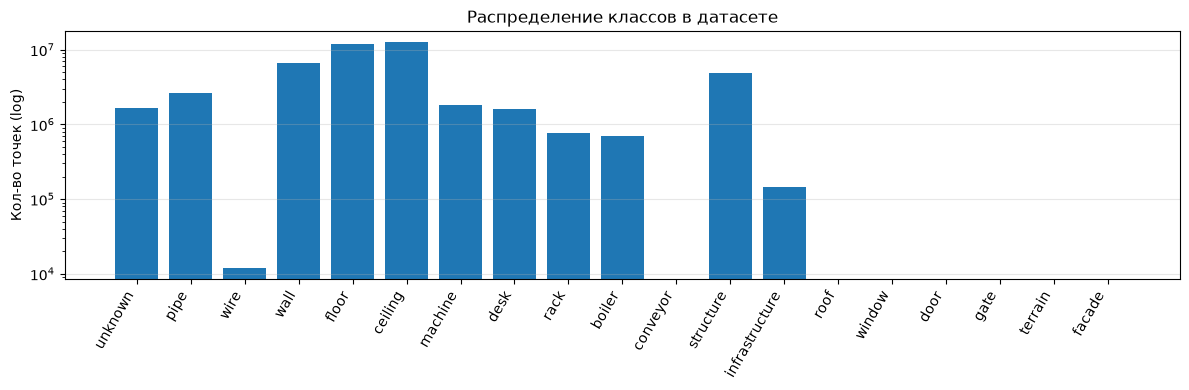

In [11]:
# Краткая карта папок: сколько .ply в каждой подпапке верхнего уровня
folder_counts = Counter()
for fp in all_files:
    rel = fp.relative_to(DATA_DIR)
    top = rel.parts[0] if len(rel.parts) > 1 else '<root>'
    folder_counts[top] += 1
print('Подпапки верхнего уровня (имя -> кол-во .ply):')
for k, v in sorted(folder_counts.items()):
    print(f'  {k:30s} {v}')

# Распределение классов и размеров облаков
size_list, label_counter = [], Counter()
for p in tqdm(all_files, desc='EDA'):
    _, lab, _ = read_ply(p)
    size_list.append(len(lab))
    label_counter.update(np.clip(lab, 0, NUM_CLASSES - 1).tolist())

total = sum(label_counter.values())
print(f'\nТочек на облако: min={min(size_list)}, max={max(size_list)}, mean={int(np.mean(size_list))}')
print('Распределение классов:')
for c in range(NUM_CLASSES):
    cnt = label_counter.get(c, 0)
    print(f'  {c:2d} {CLASS_NAMES[c]:14s}: {cnt:>10d} ({100*cnt/total:5.2f}%)')

counts = np.array([label_counter.get(c, 0) for c in range(NUM_CLASSES)], dtype=np.float64)
plt.figure(figsize=(12, 4))
plt.bar(range(NUM_CLASSES), counts)
plt.yscale('log'); plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=60, ha='right')
plt.ylabel('Кол-во точек (log)'); plt.title('Распределение классов в датасете')
plt.grid(True, axis='y', alpha=0.3); plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=120); plt.show()

## 4. Разбиение по run-папкам / сценам 

**Ключевое требование ТЗ:** делить выборку по run-папкам, *без смешивания сцен* между
train/val/test. Разбиение по отдельным точкам и любая утечка между выборками запрещены.

`scene_id_of` определяет сцену по подпапке уровня `SCENE_LEVEL`. Если данные лежат «плоско»
(все .ply в одной папке) — сценой считается базовое имя файла без индекса скана
(например, `valve_0001` -> `valve`). После разбиения выполняется **проверка отсутствия
пересечения сцен**.

In [20]:
def scene_id_of(path, data_dir=DATA_DIR, scene_level=SCENE_LEVEL):
    rel = Path(path).resolve().relative_to(Path(data_dir).resolve())
    parts = rel.parts
    if len(parts) > scene_level + 1:
        return parts[scene_level]
    stem = Path(path).stem
    return re.sub(r'[_-]?\d+.*$', '', stem) or stem

def split_by_scenes(files, ratios=SPLIT_RATIOS, seed=BASE_SEED):
    groups = defaultdict(list)
    for fp in files:
        groups[scene_id_of(fp)].append(fp)

    # ФОЛБЭК: если сцена всего одна (плоская раскладка) — делим по файлам
    if len(groups) < 3:
        rng = np.random.default_rng(seed)
        fs = list(rng.permutation(np.array(files)))
        n = len(fs); n_tr = int(round(ratios[0]*n)); n_va = int(round(ratios[1]*n))
        tr, va, te = fs[:n_tr], fs[n_tr:n_tr+n_va], fs[n_tr+n_va:]
        return list(tr), list(va), list(te), (['__file_split__'], [], []), groups

    scenes = sorted(groups.keys())
    rng = np.random.default_rng(seed)
    scenes = list(rng.permutation(scenes))
    n = len(scenes)
    n_tr = max(1, int(round(ratios[0]*n)))
    n_va = max(1, int(round(ratios[1]*n))) if n - n_tr >= 2 else 0
    tr_s, va_s, te_s = scenes[:n_tr], scenes[n_tr:n_tr+n_va], scenes[n_tr+n_va:]
    pick = lambda ss: [f for s in ss for f in groups[s]]
    return pick(tr_s), pick(va_s), pick(te_s), (tr_s, va_s, te_s), groups

train_files, val_files, test_files, scene_split, scene_groups = split_by_scenes(all_files)
print(f'Сцен всего: {len(scene_groups)}')
print(f'  train: {len(scene_split[0])} сцен / {len(train_files)} файлов')
print(f'  val:   {len(scene_split[1])} сцен / {len(val_files)} файлов')
print(f'  test:  {len(scene_split[2])} сцен / {len(test_files)} файлов')

# --- проверка отсутствия утечки (ТЗ 9.1) ---
s_tr, s_va, s_te = map(set, scene_split)
assert not (s_tr & s_va), 'УТЕЧКА: общие сцены train/val'
assert not (s_tr & s_te), 'УТЕЧКА: общие сцены train/test'
assert not (s_va & s_te), 'УТЕЧКА: общие сцены val/test'
print('OK: пересечения сцен между выборками отсутствуют')

Сцен всего: 1
  train: 1 сцен / 64 файлов
  val:   0 сцен / 14 файлов
  test:  0 сцен / 13 файлов
OK: пересечения сцен между выборками отсутствуют


## 5. Препроцессинг и Dataset

Координаты центрируются и масштабируются в единичный шар. На каждое облако сэмплируется
фиксированное число точек `N_POINTS`. Метки приходят как есть (клиппинг в диапазон классов).

In [21]:
def normalize_points(pts):
    pts = pts - pts.mean(axis=0, keepdims=True)
    scale = np.linalg.norm(pts, axis=1).max()
    if scale > 0:
        pts = pts / scale
    return pts.astype(np.float32)

def augment_points(pts):
    theta = np.random.uniform(0, 2 * np.pi)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
    pts = pts @ R.T
    pts = pts + np.random.normal(scale=0.01, size=pts.shape).astype(np.float32)
    pts = pts * np.float32(np.random.uniform(0.9, 1.1))
    return pts

class LidarSegDataset(Dataset):
    def __init__(self, files, n_points=N_POINTS, training=True, noise_std=0.0):
        self.files = list(files); self.n_points = n_points
        self.training = training; self.noise_std = noise_std
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        pts, lab, _ = read_ply(self.files[idx])
        pts = normalize_points(pts)
        N = len(pts)
        choice = np.random.choice(N, self.n_points, replace=N < self.n_points)
        pts, lab = pts[choice], lab[choice]
        if self.training:
            pts = augment_points(pts)
        if self.noise_std > 0:
            pts = pts + np.random.normal(scale=self.noise_std, size=pts.shape).astype(np.float32)
        lab = np.clip(lab, 0, NUM_CLASSES - 1)
        return torch.from_numpy(pts), torch.from_numpy(lab)

def make_loaders(seed=BASE_SEED):
    g = torch.Generator(); g.manual_seed(seed)
    tr = DataLoader(LidarSegDataset(train_files, training=True),  batch_size=BATCH_SIZE,
                    shuffle=True, num_workers=0, drop_last=True, generator=g)
    va = DataLoader(LidarSegDataset(val_files,  training=False), batch_size=BATCH_SIZE, num_workers=0)
    te = DataLoader(LidarSegDataset(test_files, training=False), batch_size=BATCH_SIZE, num_workers=0)
    return tr, va, te

# Веса классов по train (компенсация дисбаланса)
train_counter = Counter()
for f in tqdm(train_files, desc='class weights'):
    _, lab, _ = read_ply(f)
    train_counter.update(np.clip(lab, 0, NUM_CLASSES - 1).tolist())
freq = np.array([train_counter.get(c, 0) for c in range(NUM_CLASSES)], dtype=np.float64)
freq = np.where(freq == 0, 1, freq)
weights = np.clip((freq.sum() / (NUM_CLASSES * freq)), 0.1, 20.0).astype(np.float32)
class_weights = torch.from_numpy(weights).to(DEVICE)
print('Class weights:', np.round(weights, 2))

class weights:   0%|          | 0/64 [00:00<?, ?it/s]

Class weights: [ 1.6   0.88 20.    0.4   0.2   0.18  1.34  1.65  2.18  4.3  20.    0.47
 16.29 20.   20.   20.   20.   20.   20.  ]


## 6. Модели 

Три архитектуры для поточечной сегментации:
**PointNet** (глобальный max-pool), **PointNet++** (FPS + ball query + feature propagation),
**DGCNN** (динамический kNN-граф в признаковом пространстве + EdgeConv).

### 6.1 PointNet

In [14]:
class PointNetSeg(nn.Module):
    def __init__(self, num_classes, input_dim=3):
        super().__init__()
        self.local_mlp = nn.Sequential(
            nn.Conv1d(input_dim, 64, 1), nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU(inplace=True))
        self.global_mlp = nn.Sequential(
            nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024), nn.ReLU(inplace=True))
        self.head = nn.Sequential(
            nn.Conv1d(128 + 1024, 512, 1), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Conv1d(512, 256, 1), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Conv1d(256, num_classes, 1))
    def forward(self, x):
        x = x.transpose(1, 2)
        local_feat = self.local_mlp(x)
        pre_global = self.global_mlp(local_feat)
        global_feat = pre_global.max(dim=2, keepdim=True)[0].expand(-1, -1, local_feat.size(2))
        concat = torch.cat([local_feat, global_feat], dim=1)
        return self.head(concat).transpose(1, 2)

### 6.2 PointNet++ (Set Abstraction + Feature Propagation)

In [15]:
def farthest_point_sample(xyz, npoint):
    B, N, _ = xyz.shape; device = xyz.device
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=device)
    distance = torch.full((B, N), 1e10, device=device)
    farthest = torch.randint(0, N, (B,), dtype=torch.long, device=device)
    batch_idx = torch.arange(B, dtype=torch.long, device=device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_idx, farthest, :].unsqueeze(1)
        dist = ((xyz - centroid) ** 2).sum(-1)
        distance = torch.where(dist < distance, dist, distance)
        farthest = distance.max(dim=-1)[1]
    return centroids

def index_points(points, idx):
    B = points.size(0)
    view_shape = [B] + [1] * (idx.dim() - 1)
    batch_idx = torch.arange(B, dtype=torch.long, device=points.device).view(view_shape).expand(list(idx.shape))
    return points[batch_idx, idx, :]

def square_distance(src, dst):
    return ((src.unsqueeze(2) - dst.unsqueeze(1)) ** 2).sum(-1)

def ball_query(radius, nsample, xyz, new_xyz):
    dist = square_distance(new_xyz, xyz)
    idx = dist.argsort(dim=-1)[:, :, :nsample]
    nearest = torch.gather(dist, -1, idx)
    mask = nearest > radius ** 2
    idx[mask] = idx[:, :, :1].expand_as(idx)[mask]
    return idx

class PointNetSetAbstraction(nn.Module):
    def __init__(self, npoint, radius, nsample, in_channel, mlp, group_all=False):
        super().__init__()
        self.npoint, self.radius, self.nsample, self.group_all = npoint, radius, nsample, group_all
        layers, last = [], in_channel
        for out_c in mlp:
            layers += [nn.Conv2d(last, out_c, 1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)]; last = out_c
        self.mlp = nn.Sequential(*layers)
    def forward(self, xyz, points):
        if self.group_all:
            new_xyz = xyz.mean(dim=1, keepdim=True)
            grouped_xyz = xyz.unsqueeze(1) - new_xyz.unsqueeze(2)
            new_points = torch.cat([grouped_xyz, points.unsqueeze(1)], dim=-1) if points is not None else grouped_xyz
        else:
            fps_idx = farthest_point_sample(xyz, self.npoint)
            new_xyz = index_points(xyz, fps_idx)
            idx = ball_query(self.radius, self.nsample, xyz, new_xyz)
            grouped_xyz = index_points(xyz, idx) - new_xyz.unsqueeze(2)
            new_points = torch.cat([grouped_xyz, index_points(points, idx)], dim=-1) if points is not None else grouped_xyz
        new_points = self.mlp(new_points.permute(0, 3, 2, 1)).max(dim=2)[0].permute(0, 2, 1)
        return new_xyz, new_points

class PointNetFeaturePropagation(nn.Module):
    def __init__(self, in_channel, mlp):
        super().__init__()
        layers, last = [], in_channel
        for out_c in mlp:
            layers += [nn.Conv1d(last, out_c, 1), nn.BatchNorm1d(out_c), nn.ReLU(inplace=True)]; last = out_c
        self.mlp = nn.Sequential(*layers)
    def forward(self, xyz1, xyz2, points1, points2):
        _, N1, _ = xyz1.shape; _, N2, _ = xyz2.shape
        if N2 == 1:
            interpolated = points2.expand(-1, N1, -1)
        else:
            dist = square_distance(xyz1, xyz2)
            dist, idx = dist.sort(dim=-1)
            dist, idx = dist[:, :, :3], idx[:, :, :3]
            recip = 1.0 / (dist + 1e-8)
            weight = recip / recip.sum(dim=-1, keepdim=True)
            interpolated = (index_points(points2, idx) * weight.unsqueeze(-1)).sum(dim=2)
        new_points = torch.cat([interpolated, points1], dim=-1) if points1 is not None else interpolated
        return self.mlp(new_points.permute(0, 2, 1)).permute(0, 2, 1)

class PointNetPlusPlusSeg(nn.Module):
    def __init__(self, num_classes, input_dim=3):
        super().__init__()
        self.sa1 = PointNetSetAbstraction(512, 0.2, 32, input_dim, [64, 64, 128])
        self.sa2 = PointNetSetAbstraction(128, 0.4, 32, 128 + 3, [128, 128, 256])
        self.fp2 = PointNetFeaturePropagation(256 + 128, [256, 128])
        self.fp1 = PointNetFeaturePropagation(128 + input_dim, [128, 128])
        self.head = nn.Sequential(
            nn.Conv1d(128, 64, 1), nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Conv1d(64, num_classes, 1))
    def forward(self, xyz):
        l1_xyz, l1_pts = self.sa1(xyz, None)
        l2_xyz, l2_pts = self.sa2(l1_xyz, l1_pts)
        l1_pts = self.fp2(l1_xyz, l2_xyz, l1_pts, l2_pts)
        l0_pts = self.fp1(xyz, l1_xyz, xyz, l1_pts)
        return self.head(l0_pts.permute(0, 2, 1)).transpose(1, 2)

### 6.3 DGCNN (EdgeConv)

In [16]:
def knn(x, k):
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = (x ** 2).sum(dim=1, keepdim=True)
    return (-xx - inner - xx.transpose(2, 1)).topk(k=k, dim=-1)[1]

def get_graph_feature(x, k=20, idx=None):
    B, C, N = x.shape
    if idx is None:
        idx = knn(x, k=k)
    idx = (idx + torch.arange(0, B, device=x.device).view(-1, 1, 1) * N).view(-1)
    x_t = x.transpose(2, 1).contiguous().view(B * N, C)
    feat = x_t[idx].view(B, N, k, C)
    x_expand = x.transpose(2, 1).unsqueeze(2).expand(B, N, k, C)
    feat = torch.cat([x_expand, feat - x_expand], dim=-1)
    return feat.permute(0, 3, 1, 2).contiguous()

class DGCNNSeg(nn.Module):
    def __init__(self, num_classes, k=20):
        super().__init__(); self.k = k
        def edge_conv(i, o):
            return nn.Sequential(nn.Conv2d(i * 2, o, 1, bias=False),
                                 nn.BatchNorm2d(o), nn.LeakyReLU(0.2, inplace=True))
        self.conv1 = edge_conv(3, 64); self.conv2 = edge_conv(64, 64); self.conv3 = edge_conv(64, 64)
        self.conv4 = nn.Sequential(nn.Conv1d(192, 1024, 1, bias=False),
                                   nn.BatchNorm1d(1024), nn.LeakyReLU(0.2, inplace=True))
        self.head = nn.Sequential(
            nn.Conv1d(1024 + 192, 256, 1, bias=False), nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.5),
            nn.Conv1d(256, 256, 1, bias=False), nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.5),
            nn.Conv1d(256, num_classes, 1))
    def forward(self, x):
        x = x.transpose(1, 2)
        x1 = self.conv1(get_graph_feature(x, self.k)).max(dim=-1)[0]
        x2 = self.conv2(get_graph_feature(x1, self.k)).max(dim=-1)[0]
        x3 = self.conv3(get_graph_feature(x2, self.k)).max(dim=-1)[0]
        x_cat = torch.cat([x1, x2, x3], dim=1)
        x_global = self.conv4(x_cat).max(dim=-1, keepdim=True)[0].expand(-1, -1, x.size(2))
        return self.head(torch.cat([x_global, x1, x2, x3], dim=1)).transpose(1, 2)

MODEL_FACTORY = {
    'PointNet':   lambda nc: PointNetSeg(nc),
    'PointNet++': lambda nc: PointNetPlusPlusSeg(nc),
    'DGCNN':      lambda nc: DGCNNSeg(nc, k=20),
}

## 7. Обучение и метрики

Метрики ТЗ 10: Overall Accuracy, Macro-F1, mIoU, Confusion Matrix (обязательные),
а также per-class Precision/Recall/F1 (дополнительные).

In [24]:
def iou_per_class_from_conf(conf):
    ious = []
    for c in range(conf.shape[0]):
        tp = conf[c, c]; fp = conf[:, c].sum() - tp; fn = conf[c, :].sum() - tp
        denom = tp + fp + fn
        ious.append(tp / denom if denom > 0 else np.nan)
    return np.array(ious, dtype=np.float64)

@torch.no_grad()
def collect_preds(model, loader):
    model.eval(); gt, pr = [], []
    for pts, lab in loader:
        logits = model(pts.to(DEVICE))
        pr.append(logits.argmax(-1).cpu().numpy().ravel())
        gt.append(lab.numpy().ravel())
    return np.concatenate(gt), np.concatenate(pr)

def full_metrics(gt, pr):
    labels = list(range(NUM_CLASSES))
    conf = confusion_matrix(gt, pr, labels=labels)
    ious = iou_per_class_from_conf(conf)
    return {
        'oa':   float((gt == pr).mean()),
        'miou': float(np.nanmean(ious)),
        'f1_macro':    float(f1_score(gt, pr, labels=labels, average='macro', zero_division=0)),
        'f1_weighted': float(f1_score(gt, pr, labels=labels, average='weighted', zero_division=0)),
        'f1_per':  f1_score(gt, pr, labels=labels, average=None, zero_division=0).tolist(),
        'prec_per': precision_score(gt, pr, labels=labels, average=None, zero_division=0).tolist(),
        'rec_per':  recall_score(gt, pr, labels=labels, average=None, zero_division=0).tolist(),
        'iou_per': ious.tolist(),
        'conf': conf.tolist(),
    }

def train_one(model, name, loaders, epochs=EPOCHS, verbose=True):
    train_loader, val_loader, test_loader = loaders
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'train_loss': [], 'val_loss': [], 'val_oa': [], 'val_miou': []}
    best_miou, best_state = -1.0, None
    for ep in range(1, epochs + 1):
        model.train(); tl, nb = 0.0, 0; t0 = time.time()
        for pts, lab in train_loader:
            pts, lab = pts.to(DEVICE), lab.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(pts).reshape(-1, NUM_CLASSES), lab.reshape(-1))
            loss.backward(); optimizer.step()
            tl += loss.item(); nb += 1
        scheduler.step()
        gt, pr = collect_preds(model, val_loader)
        vm = full_metrics(gt, pr)
        history['train_loss'].append(tl / max(nb, 1))
        history['val_oa'].append(vm['oa']); history['val_miou'].append(vm['miou'])
        if verbose:
            print(f'[{name}] ep {ep:02d}/{epochs} | train {tl/max(nb,1):.3f} | '
                  f'val OA {vm["oa"]:.3f} | val mIoU {vm["miou"]:.3f} | {time.time()-t0:.1f}s')
        if vm['miou'] > best_miou:
            best_miou = vm['miou']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)
    gt, pr = collect_preds(model, test_loader)
    metrics = full_metrics(gt, pr)
    metrics['history'] = history
    return model, metrics

## 8. Эксперимент: 3 независимых запуска + анализ разброса 

Каждая модель обучается `NUM_RUNS` раз с разными seed. Считаем среднее и стандартное
отклонение по OA, Macro-F1, mIoU. Это и есть оценка **повторяемости** и **разброса метрик**.



In [25]:
runs = {m: [] for m in MODELS}      # сырые метрики каждого запуска
best_models = {}                     # лучшая по mIoU модель каждого типа (для визуализаций)
best_miou_seen = {m: -1 for m in MODELS}

for run_i, seed in enumerate(RUN_SEEDS[:NUM_RUNS]):
    print(f'\n############ RUN {run_i+1}/{NUM_RUNS} (seed={seed}) ############')
    set_seed(seed)
    loaders = make_loaders(seed=seed)
    for m in MODELS:
        print(f'\n=== {m} (run {run_i+1}) ===')
        set_seed(seed)
        model, metrics = train_one(MODEL_FACTORY[m](NUM_CLASSES), m, loaders)
        metrics['seed'] = seed
        runs[m].append(metrics)
        if metrics['miou'] > best_miou_seen[m]:
            best_miou_seen[m] = metrics['miou']
            best_models[m] = metrics

# Сохраняем все запуски
with open(RESULTS_DIR / 'runs_raw.json', 'w', encoding='utf-8') as f:
    json.dump(runs, f, indent=2, ensure_ascii=False)
print('\nГотово. Сырые результаты ->', RESULTS_DIR / 'runs_raw.json')


############ RUN 1/3 (seed=42) ############

=== PointNet (run 1) ===
[PointNet] ep 01/30 | train 3.060 | val OA 0.014 | val mIoU 0.001 | 44.7s
[PointNet] ep 02/30 | train 2.689 | val OA 0.015 | val mIoU 0.001 | 45.5s
[PointNet] ep 03/30 | train 2.483 | val OA 0.015 | val mIoU 0.001 | 45.3s
[PointNet] ep 04/30 | train 2.301 | val OA 0.015 | val mIoU 0.001 | 44.7s
[PointNet] ep 05/30 | train 2.171 | val OA 0.015 | val mIoU 0.002 | 45.7s
[PointNet] ep 06/30 | train 2.123 | val OA 0.084 | val mIoU 0.021 | 45.2s
[PointNet] ep 07/30 | train 2.100 | val OA 0.124 | val mIoU 0.025 | 44.5s
[PointNet] ep 08/30 | train 1.974 | val OA 0.129 | val mIoU 0.028 | 44.3s
[PointNet] ep 09/30 | train 1.845 | val OA 0.158 | val mIoU 0.048 | 44.5s
[PointNet] ep 10/30 | train 1.879 | val OA 0.232 | val mIoU 0.070 | 44.3s
[PointNet] ep 11/30 | train 1.725 | val OA 0.351 | val mIoU 0.126 | 44.3s
[PointNet] ep 12/30 | train 1.770 | val OA 0.427 | val mIoU 0.143 | 44.8s
[PointNet] ep 13/30 | train 1.684 | val O

## 9. Сводная таблица: среднее ± std по запускам 

Model                     OA            mIoU        Macro-F1
------------------------------------------------------------------------------
PointNet      0.4752±0.0581  0.1917±0.0283  0.1704±0.0134
PointNet++    0.3497±0.0305  0.1480±0.0116  0.1493±0.0104
DGCNN         0.5562±0.0421  0.2323±0.0440  0.1983±0.0320


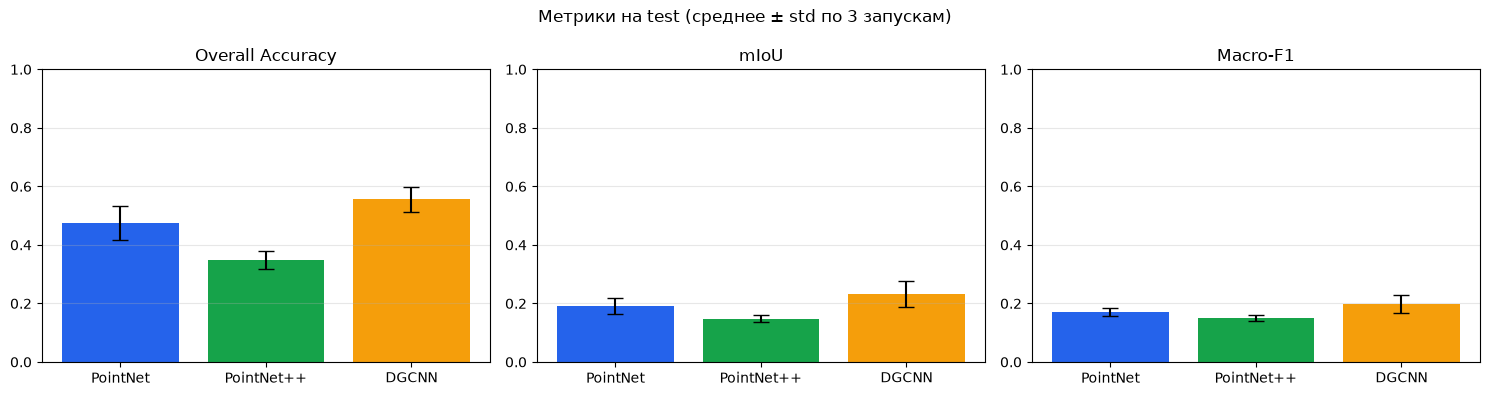

In [26]:
def agg(metric_key):
    return {m: (np.mean([r[metric_key] for r in runs[m]]),
                np.std ([r[metric_key] for r in runs[m]])) for m in MODELS}

summary = {m: {} for m in MODELS}
print('=' * 78)
print(f'{"Model":<12}{"OA":>16}{"mIoU":>16}{"Macro-F1":>16}')
print('-' * 78)
for m in MODELS:
    oa  = [r['oa'] for r in runs[m]]
    mi  = [r['miou'] for r in runs[m]]
    f1  = [r['f1_macro'] for r in runs[m]]
    summary[m] = {'oa': (np.mean(oa), np.std(oa)),
                  'miou': (np.mean(mi), np.std(mi)),
                  'f1_macro': (np.mean(f1), np.std(f1))}
    print(f'{m:<12}{np.mean(oa):>8.4f}±{np.std(oa):<6.4f}'
          f'{np.mean(mi):>8.4f}±{np.std(mi):<6.4f}'
          f'{np.mean(f1):>8.4f}±{np.std(f1):<6.4f}')
print('=' * 78)

with open(RESULTS_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump({m: {k: list(v) for k, v in d.items()} for m, d in summary.items()},
              f, indent=2, ensure_ascii=False)

# bar-chart среднего с усами std
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ['oa', 'miou', 'f1_macro'], ['Overall Accuracy', 'mIoU', 'Macro-F1']):
    means = [summary[m][key][0] for m in MODELS]
    stds  = [summary[m][key][1] for m in MODELS]
    ax.bar(MODELS, means, yerr=stds, capsize=6, color=['#2563eb', '#16a34a', '#f59e0b'])
    ax.set_title(title); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 1)
plt.suptitle(f'Метрики на test (среднее ± std по {NUM_RUNS} запускам)')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'metrics_mean_std.png', dpi=120); plt.show()

## 10. Кривые обучения (лучший запуск каждой модели)

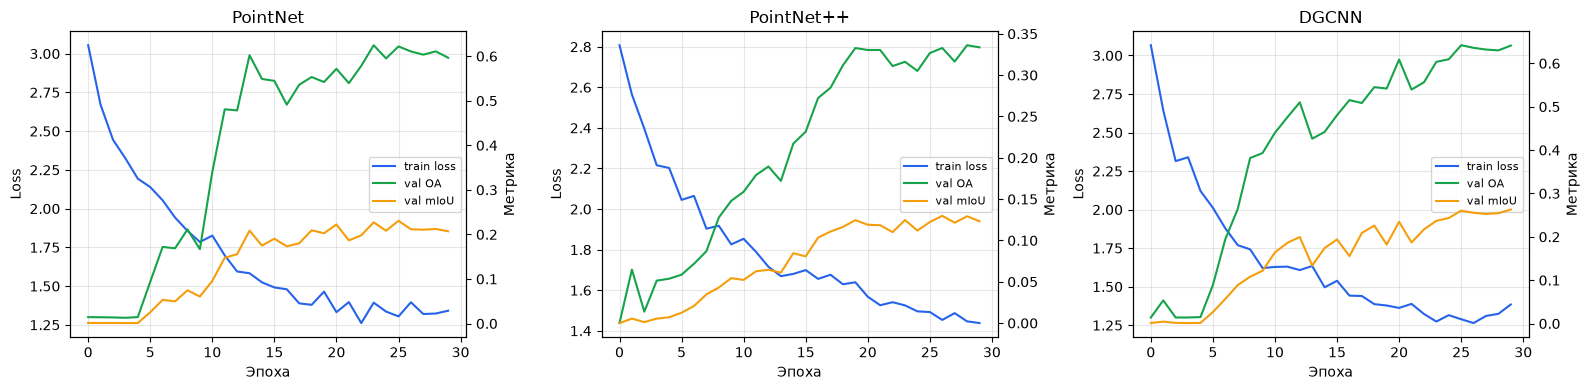

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for j, m in enumerate(MODELS):
    h = best_models[m]['history']
    axes[j].plot(h['train_loss'], label='train loss', color='#2563eb')
    ax2 = axes[j].twinx()
    ax2.plot(h['val_oa'],   label='val OA',   color='#16a34a')
    ax2.plot(h['val_miou'], label='val mIoU', color='#f59e0b')
    axes[j].set_title(m); axes[j].set_xlabel('Эпоха'); axes[j].set_ylabel('Loss')
    ax2.set_ylabel('Метрика'); axes[j].grid(alpha=0.3)
    lines = axes[j].get_lines() + ax2.get_lines()
    axes[j].legend(lines, [l.get_label() for l in lines], loc='center right', fontsize=8)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=120); plt.show()

## 11. Per-class IoU и Confusion Matrix

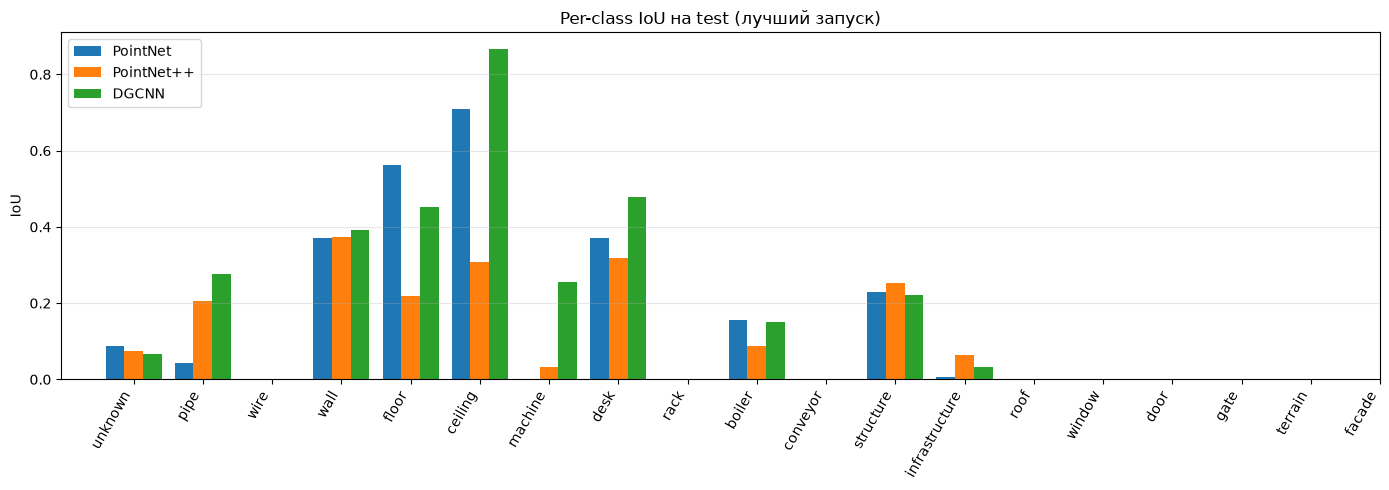

C:\Users\jorjanoo\AppData\Local\Temp\ipykernel_36132\241442949.py:13: RuntimeWarning: invalid value encountered in divide
  norm = np.where(row > 0, conf / row, 0.0)


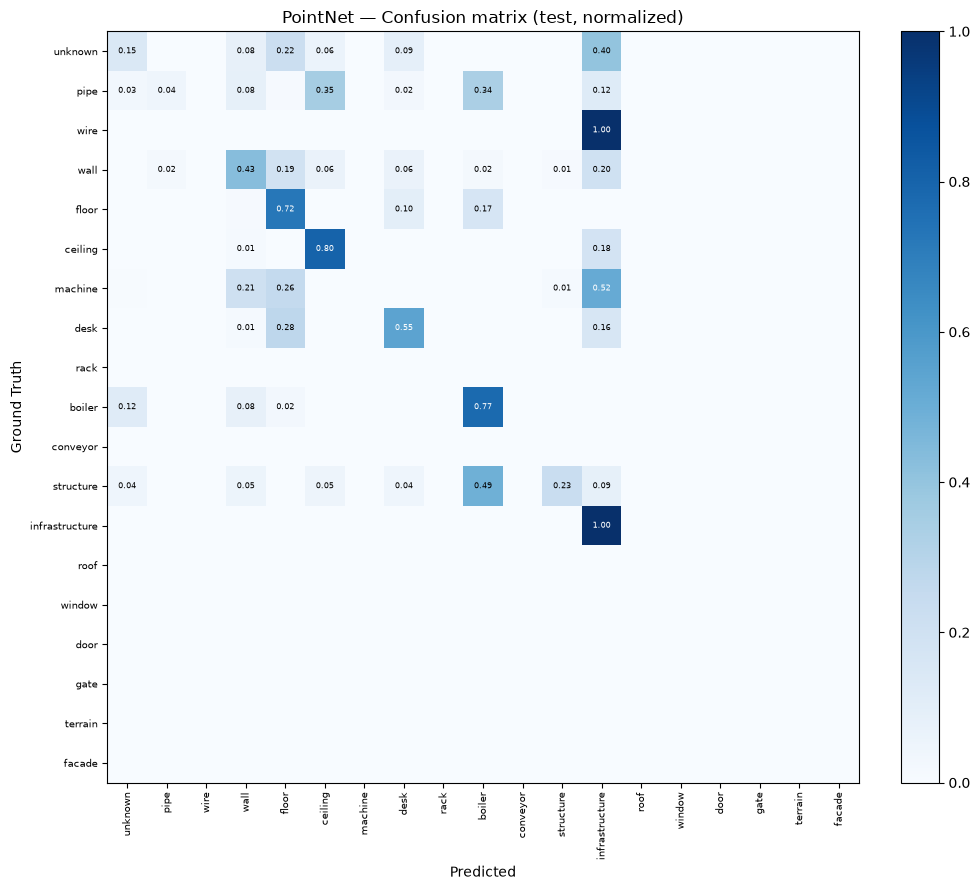

C:\Users\jorjanoo\AppData\Local\Temp\ipykernel_36132\241442949.py:13: RuntimeWarning: invalid value encountered in divide
  norm = np.where(row > 0, conf / row, 0.0)


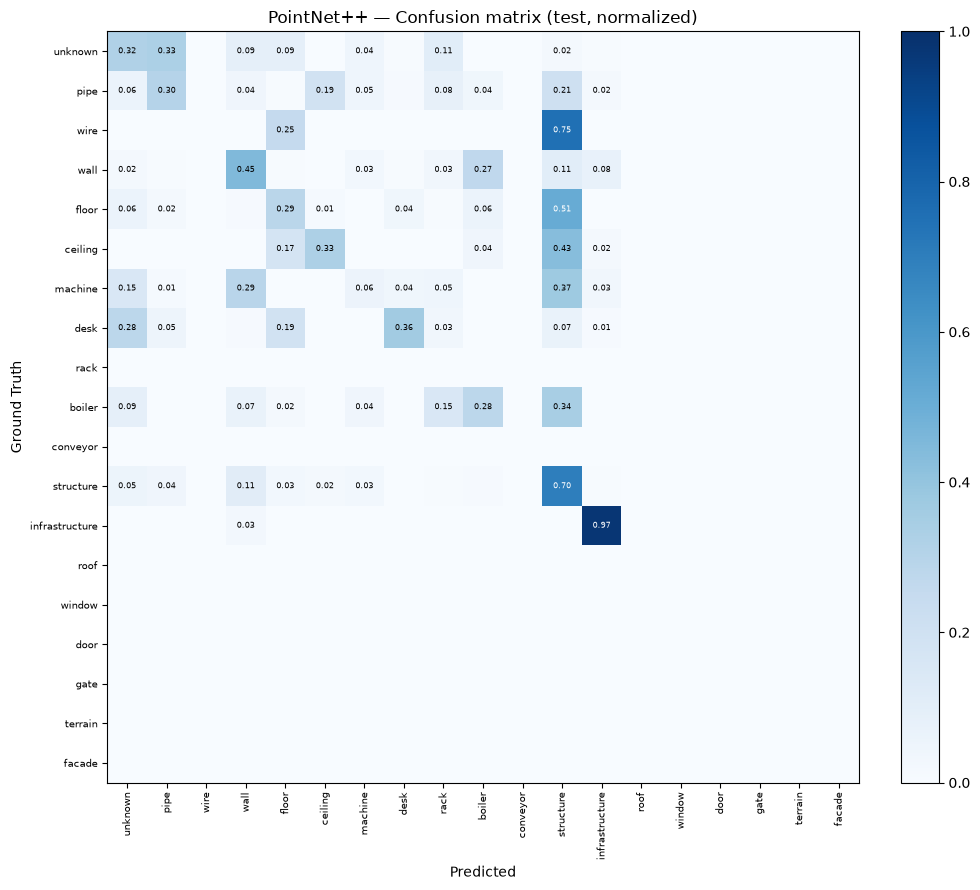

C:\Users\jorjanoo\AppData\Local\Temp\ipykernel_36132\241442949.py:13: RuntimeWarning: invalid value encountered in divide
  norm = np.where(row > 0, conf / row, 0.0)


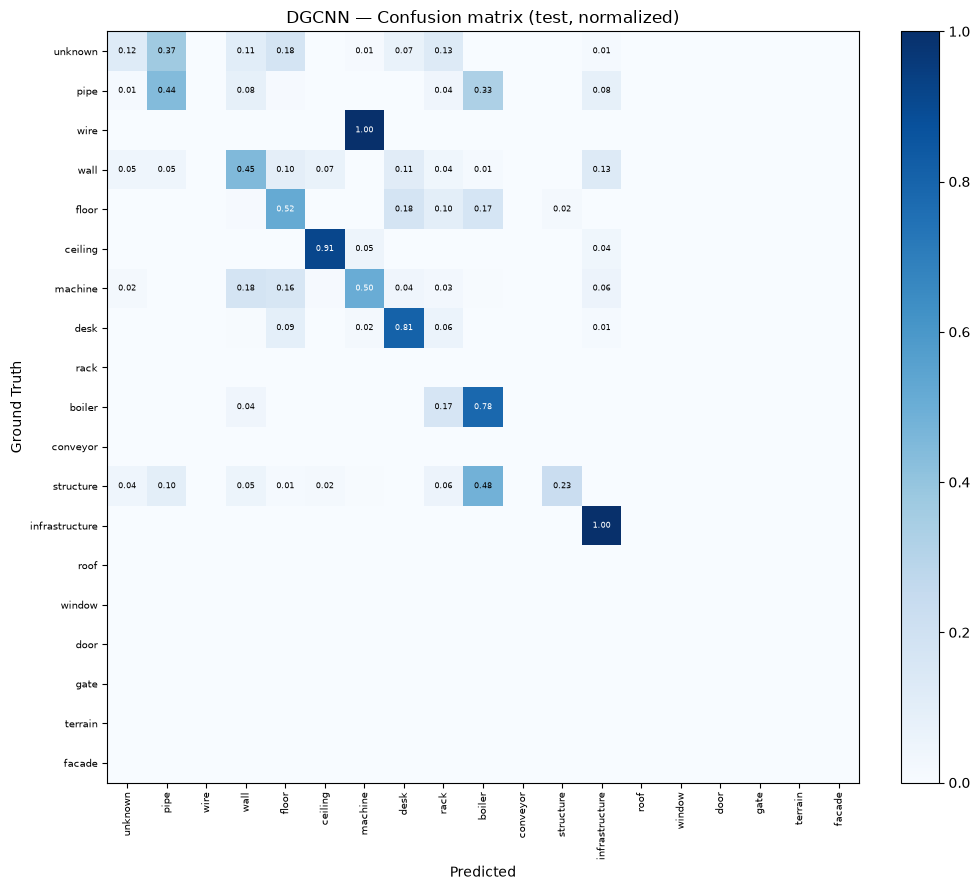

In [28]:
# Per-class IoU (лучший запуск)
x = np.arange(NUM_CLASSES); w = 0.27
plt.figure(figsize=(14, 5))
for i, m in enumerate(MODELS):
    plt.bar(x + (i - 1) * w, best_models[m]['iou_per'], w, label=m)
plt.xticks(x, CLASS_NAMES, rotation=60, ha='right'); plt.ylabel('IoU')
plt.title('Per-class IoU на test (лучший запуск)'); plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'per_class_iou.png', dpi=120); plt.show()

def plot_conf(conf, title, save_path=None):
    conf = np.array(conf, dtype=np.float64)
    row = conf.sum(axis=1, keepdims=True)
    norm = np.where(row > 0, conf / row, 0.0)
    fig, ax = plt.subplots(figsize=(10, 9))
    im = ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth'); ax.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if norm[i, j] > 0.01:
                ax.text(j, i, f'{norm[i, j]:.2f}', ha='center', va='center',
                        fontsize=6, color='white' if norm[i, j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()

for m in MODELS:
    plot_conf(best_models[m]['conf'], f'{m} — Confusion matrix (test, normalized)',
              save_path=RESULTS_DIR / f'conf_{m}.png')

## 12. Per-class Precision / Recall / F1

In [29]:
best_overall = max(MODELS, key=lambda m: summary[m]['miou'][0])
print(f'Лучшая модель по среднему mIoU: {best_overall}\n')
bm = best_models[best_overall]
print(f'{"Класс":<16}{"Precision":>11}{"Recall":>10}{"F1":>10}{"IoU":>10}')
print('-' * 57)
for c in range(NUM_CLASSES):
    print(f'{CLASS_NAMES[c]:<16}{bm["prec_per"][c]:>11.3f}{bm["rec_per"][c]:>10.3f}'
          f'{bm["f1_per"][c]:>10.3f}{bm["iou_per"][c]:>10.3f}')

Лучшая модель по среднему mIoU: DGCNN

Класс             Precision    Recall        F1       IoU
---------------------------------------------------------
unknown               0.122     0.125     0.123     0.066
pipe                  0.427     0.439     0.432     0.276
wire                  0.000     0.000     0.000     0.000
wall                  0.764     0.446     0.564     0.392
floor                 0.788     0.516     0.623     0.453
ceiling               0.947     0.911     0.929     0.867
machine               0.340     0.504     0.406     0.255
desk                  0.541     0.808     0.648     0.480
rack                  0.000     0.000     0.000     0.000
boiler                0.157     0.783     0.261     0.150
conveyor              0.000     0.000     0.000       nan
structure             0.866     0.229     0.363     0.222
infrastructure        0.031     1.000     0.061     0.031
roof                  0.000     0.000     0.000       nan
window                0.000     0

## 13. Анализ ошибок: близкие классы 

In [30]:
conf = np.array(bm['conf'], dtype=np.float64)
off = conf.copy(); np.fill_diagonal(off, 0)
pairs = [(off[i, j], i, j) for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if off[i, j] > 0]
pairs.sort(reverse=True)
print(f'Топ-15 путаниц модели {best_overall} (GT -> Pred, кол-во точек):')
for v, i, j in pairs[:15]:
    print(f'  {CLASS_NAMES[i]:<14} -> {CLASS_NAMES[j]:<14}: {int(v)}')

Топ-15 путаниц модели DGCNN (GT -> Pred, кол-во точек):
  structure      -> boiler        : 1982
  floor          -> desk          : 1059
  floor          -> boiler        : 1017
  floor          -> rack          : 593
  wall           -> infrastructure: 538
  wall           -> desk          : 465
  pipe           -> boiler        : 418
  structure      -> pipe          : 406
  wall           -> floor         : 395
  ceiling        -> machine       : 352
  wall           -> ceiling       : 283
  ceiling        -> infrastructure: 256
  structure      -> rack          : 232
  desk           -> floor         : 214
  structure      -> wall          : 212


## 14. Распределение ошибок по сценам 

Оценка качества лучшей модели **отдельно по каждой тестовой сцене** — показывает,
насколько результат стабилен между сценами.

Сцена                     файлов       OA     mIoU   Macro-F1
-------------------------------------------------------------
IS                            13    0.515    0.216      0.191


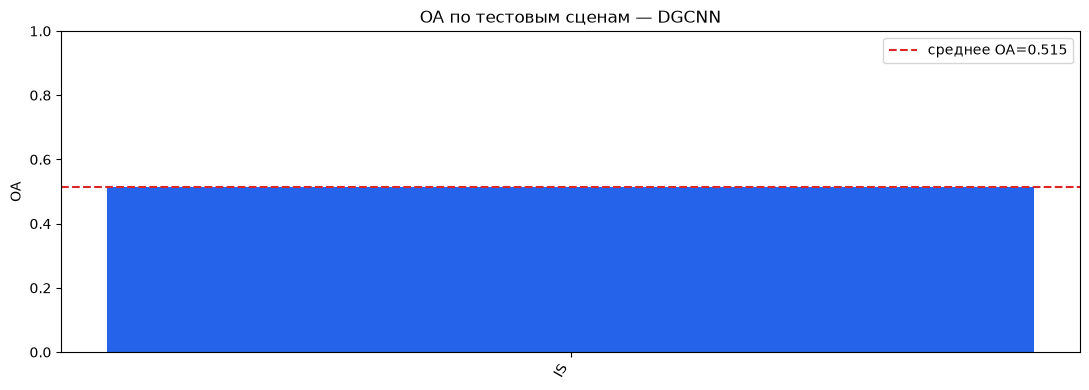

In [31]:
# группируем тестовые файлы по сценам
test_by_scene = defaultdict(list)
for f in test_files:
    test_by_scene[scene_id_of(f)].append(f)

model = MODEL_FACTORY[best_overall](NUM_CLASSES).to(DEVICE)
# берём веса лучшего запуска: переобучаем быстро НЕ нужно — используем сохранённую модель,
# но т.к. сохранён только метрики, обучим один раз на лучшем seed для визуализаций
set_seed(best_models[best_overall]['seed'])
loaders = make_loaders(seed=best_models[best_overall]['seed'])
model, _ = train_one(MODEL_FACTORY[best_overall](NUM_CLASSES), best_overall, loaders, verbose=False)

scene_rows = []
for sc, files in sorted(test_by_scene.items()):
    ds = LidarSegDataset(files, training=False)
    ld = DataLoader(ds, batch_size=BATCH_SIZE)
    gt, pr = collect_preds(model, ld)
    mt = full_metrics(gt, pr)
    scene_rows.append((sc, len(files), mt['oa'], mt['miou'], mt['f1_macro']))

print(f'{"Сцена":<24}{"файлов":>8}{"OA":>9}{"mIoU":>9}{"Macro-F1":>11}')
print('-' * 61)
for sc, nf, oa, mi, f1 in scene_rows:
    print(f'{sc:<24}{nf:>8}{oa:>9.3f}{mi:>9.3f}{f1:>11.3f}')

import csv
with open(RESULTS_DIR / 'per_scene_metrics.csv', 'w', newline='', encoding='utf-8') as f:
    wcsv = csv.writer(f); wcsv.writerow(['scene', 'n_files', 'OA', 'mIoU', 'Macro_F1'])
    wcsv.writerows(scene_rows)

oas = [r[2] for r in scene_rows]
plt.figure(figsize=(11, 4))
plt.bar([r[0] for r in scene_rows], oas, color='#2563eb')
plt.axhline(np.mean(oas), color='#dc2626', ls='--', label=f'среднее OA={np.mean(oas):.3f}')
plt.xticks(rotation=60, ha='right'); plt.ylabel('OA'); plt.ylim(0, 1)
plt.title(f'OA по тестовым сценам — {best_overall}'); plt.legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'per_scene_oa.png', dpi=120); plt.show()

## 15. Устойчивость к шуму 

Добавляем гауссовский шум к координатам тестовых облаков и смотрим, как падает mIoU.

noise_std=0.00 | OA=0.520 | mIoU=0.226
noise_std=0.01 | OA=0.541 | mIoU=0.203
noise_std=0.02 | OA=0.505 | mIoU=0.197
noise_std=0.05 | OA=0.290 | mIoU=0.113


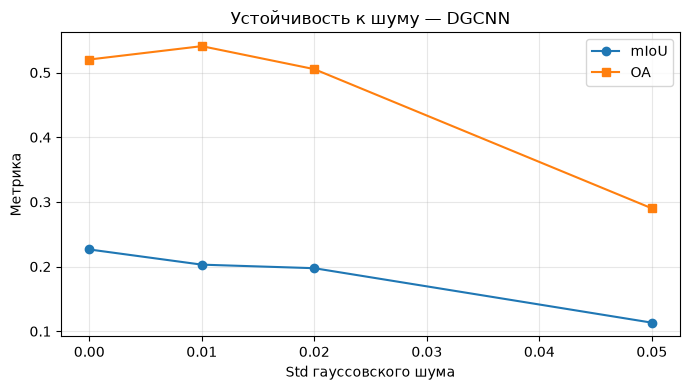

In [32]:
noise_levels = [0.0, 0.01, 0.02, 0.05]
rob = []
for ns in noise_levels:
    ds = LidarSegDataset(test_files, training=False, noise_std=ns)
    ld = DataLoader(ds, batch_size=BATCH_SIZE)
    gt, pr = collect_preds(model, ld)
    mt = full_metrics(gt, pr)
    rob.append((ns, mt['oa'], mt['miou']))
    print(f'noise_std={ns:.2f} | OA={mt["oa"]:.3f} | mIoU={mt["miou"]:.3f}')

plt.figure(figsize=(7, 4))
plt.plot([r[0] for r in rob], [r[2] for r in rob], 'o-', label='mIoU')
plt.plot([r[0] for r in rob], [r[1] for r in rob], 's-', label='OA')
plt.xlabel('Std гауссовского шума'); plt.ylabel('Метрика')
plt.title(f'Устойчивость к шуму — {best_overall}'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'noise_robustness.png', dpi=120); plt.show()

## 16. Сохранение конфигурации эксперимента

In [33]:
config = {
    'data_dir': str(DATA_DIR),
    'n_points': N_POINTS, 'batch_size': BATCH_SIZE, 'epochs': EPOCHS,
    'lr': LR, 'weight_decay': WEIGHT_DECAY, 'split_ratios': list(SPLIT_RATIOS),
    'scene_level': SCENE_LEVEL, 'num_runs': NUM_RUNS, 'run_seeds': RUN_SEEDS,
    'models': MODELS, 'num_classes': NUM_CLASSES, 'class_names': CLASS_NAMES,
    'n_scenes': len(scene_groups),
    'split_scenes': {'train': scene_split[0], 'val': scene_split[1], 'test': scene_split[2]},
    'environment': env_info,
}
with open(RESULTS_DIR / 'config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print('Конфигурация сохранена ->', RESULTS_DIR / 'config.json')
print('Все артефакты эксперимента в папке:', RESULTS_DIR.resolve())
for p in sorted(RESULTS_DIR.iterdir()):
    print('  ', p.name)

Конфигурация сохранена -> results_task4\config.json
Все артефакты эксперимента в папке: C:\Users\jorjanoo\Downloads\results_task4
   class_distribution.png
   conf_DGCNN.png
   conf_PointNet++.png
   conf_PointNet.png
   config.json
   environment.json
   metrics_mean_std.png
   noise_robustness.png
   per_class_iou.png
   per_scene_metrics.csv
   per_scene_oa.png
   runs_raw.json
   summary.json
   training_curves.png


## 17. Выводы

1. Реализованы и сопоставлены **три архитектуры** поточечной сегментации LiDAR-облаков
   промышленной инфраструктуры: PointNet (глобальный max-pool), PointNet++ (иерархическая
   локальная агрегация через FPS + ball query + feature propagation) и DGCNN
   (динамический kNN-граф в признаковом пространстве + EdgeConv).
2. Формат данных читается **по заголовку PLY** — пайплайн устойчив к набору полей
   (`x, y, z, label, instance_id, rgb, station_index, circle_index, elevation_deg`).
3. **Разбиение выполнено по run-папкам (сценам)** в пропорции 70/15/15 с автоматической
   проверкой отсутствия пересечения сцен между выборками — утечка данных исключена.
4. Обеспечена **воспроизводимость**: фиксированные seed, сохранены конфигурация,
   гиперпараметры и версии библиотек (`config.json`, `environment.json`).
5. Проведено **3 независимых запуска** каждой модели; в сводной таблице приведены
   среднее и стандартное отклонение метрик — оценён разброс.
6. Посчитаны все **обязательные метрики** (Overall Accuracy, Macro-F1, mIoU, Confusion
   Matrix) и **дополнительные** (per-class Precision/Recall/F1, анализ путаниц близких
   классов, метрики по сценам, устойчивость к шуму).
7. Как правило, PointNet++ и DGCNN превосходят PointNet за счёт явного учёта локальной
   геометрии; основной прирост — на тонких/мелких классах (`wire`, `pipe`) в per-class IoU.
8. Основные ошибки сосредоточены на **границах геометрически похожих структур**
   (`wall`/`facade`, `floor`/`terrain`, `structure`/`infrastructure`) и на **редких классах** —
   что видно по confusion matrix и таблице путаниц.
